<a href="https://colab.research.google.com/github/anmyvla-beep/python-ai-Mysttonen-Angelika/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV-файлов о телесериалах

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем два CSV-файла:

tvserialone.csv — 1224 записи о наградах для 294 сериалов
tvserialtwo.csv — 2679 записей о тематике для 1878 сериалов

- Очищаем столбцы в обоих датасетах:

- Удаляем URL Wikidata (tv_series)
- Переименовываем *Label → короткие имена (tv_seriesLabel → tv_series, awardLabel → award, subjectLabel → subject)
- Приводим числовые поля (start_year, end_year) к типу int
- Проверяем структуру и первые строки
**Результат:** Два чистых датафрейма

📺 df_one (сериалы с наградами):

- `tv_series — название сериала
- `start_year — год начала
- `end_year — год окончания
- `award — название награды/номинации
- `subject — тема/категория номинации
📺 df_two (сериалы с тематикой):

tv_series — название сериала
start_year — год начала
end_year — год окончания
subject — тема/сюжетная линия

In [16]:
# 📊 Week 3: Визуализация данных о телесериалах
# Полная подготовка данных (исправленная, без заполнения нулями)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Библиотеки импортированы.")

# --- Клонирование репозитория и переход в папку ---
repo_name = "python-ai-Mysttonen-Angelika"
repo_url = f"https://github.com/anmyvla-beep/{repo_name}.git"

if not os.path.exists(repo_name):
    !git clone -q {repo_url}
    print(f"✅ Репозиторий {repo_name} склонирован.")
else:
    print(f"ℹ️ Репозиторий {repo_name} уже существует.")

%cd {repo_name}

# --- Загрузка исходных CSV-файлов ---
print("\n📂 Загрузка исходных данных...")
df_tv_one = pd.read_csv("data/tvserialone.csv")
df_tv_two = pd.read_csv("data/tvserialtwo.csv")
df_country = pd.read_csv("data/tvseriescountry.csv")

print(f"✅ tvserialone.csv: {df_tv_one.shape}")
print(f"✅ tvserialtwo.csv: {df_tv_two.shape}")
print(f"✅ tvseriescountry.csv: {df_country.shape}")

# --- Функция для первичной очистки (сохраняем URI, НЕ заполняем годы нулями) ---
def clean_tv_dataset(df, name):
    df_clean = df.copy()
    if "tv_seriesLabel" in df_clean.columns:
        if "tv_series" in df_clean.columns:
            df_clean = df_clean.rename(columns={"tv_series": "tv_series_uri"})
        rename_map = {
            "tv_seriesLabel": "tv_series_name",
            "subjectLabel": "subject"
        }
        if "awardLabel" in df_clean.columns:
            rename_map["awardLabel"] = "award"
        df_clean = df_clean.rename(columns=rename_map)
        # Преобразуем в числа, оставляем NaN для пропусков
        for col in ["start_year", "end_year"]:
            if col in df_clean.columns:
                df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
        print(f"✅ {name}: очищено (сохранён tv_series_uri)")
    else:
        print(f"ℹ️ {name}: уже очищен?")
    return df_clean

# Очищаем датасеты
df_tv_one_clean = clean_tv_dataset(df_tv_one, "Датасет 1 (награды)")
df_tv_two_clean = clean_tv_dataset(df_tv_two, "Датасет 2 (тематика)")
df_country_clean = clean_tv_dataset(df_country, "Датасет стран")
df_country_clean = df_country_clean.rename(columns={"countryLabel": "country"})

# --- Добавляем временный флаг наличия награды ---
df_tv_one_clean['has_award_temp'] = True
df_tv_two_clean['has_award_temp'] = False

# --- Объединяем оба датасета с темами ---
df_themes_raw = pd.concat([
    df_tv_one_clean[['tv_series_uri', 'tv_series_name', 'start_year', 'end_year', 'subject', 'has_award_temp']],
    df_tv_two_clean[['tv_series_uri', 'tv_series_name', 'start_year', 'end_year', 'subject', 'has_award_temp']]
], ignore_index=True)

df_themes_raw = df_themes_raw.dropna(subset=['subject']).copy()

# --- Функция кластеризации тем (как в Week 2) ---
def cluster_subject(subject):
    if pd.isna(subject): return "Прочее"
    s = str(subject).lower().strip()
    if any(w in s for w in ["войн","воен","солдат","армия","боец","сражение","фронт"]): return "Война и история"
    if any(w in s for w in ["политик","президент","правитель","парламент","выборы","депутат"]): return "Политика"
    if any(w in s for w in ["полиц","криминал","детектив","убийств","преступ","следств","шериф","мафия","наркотик"]): return "Криминал и детектив"
    if any(w in s for w in ["семь","брак","любов","отношен","дружб","родител","дет","брат","сестр","роман"]): return "Семья и отношения"
    if any(w in s for w in ["врач","больниц","медицина","наук","лаборатор","исследован","профессор","психолог"]): return "Наука и медицина"
    if any(w in s for w in ["космос","инопланет","фантаст","робот","технолог","будущее","кибер","научная фантастика"]): return "Фантастика и технологии"
    if any(w in s for w in ["маги","ведьм","привиден","демон","сверхъестеств","заклинан","призрак"]): return "Мистика и магия"
    if any(w in s for w in ["спорт","футбол","баскетбол","хоккей","олимпиад","чемпионат","тренер","игрок"]): return "Спорт"
    if any(w in s for w in ["бизнес","компани","деньги","богат","корпорац","финанс","рынок","предприниматель"]): return "Бизнес и финансы"
    if any(w in s for w in ["актёр","режиссёр","музык","певец","шоу","телевиден","кино","театр","танец"]): return "Шоу-бизнес и искусство"
    if any(w in s for w in ["животн","природа","джунгли","охот","рыбалк","зоопарк","ферма","экология"]): return "Природа и животные"
    if any(w in s for w in ["школ","университет","студент","учител","образован","колледж","курс"]): return "Образование"
    if any(w in s for w in ["религ","церков","бог","монастыр","святой","мусульм","христиан","буддизм"]): return "Религия"
    if any(w in s for w in ["суд","адвокат","прокурор","юрист","закон","тюрьма","следователь"]): return "Юриспруденция"
    if any(w in s for w in ["еда","кулинар","ресторан","повар","рецепт","кухня"]): return "Еда и кулинария"
    return "Прочее"

df_themes_raw['subject_cluster'] = df_themes_raw['subject'].apply(cluster_subject)

# --- Присоединяем страну из df_country_clean ---
df_themes_for_time = df_themes_raw.merge(
    df_country_clean[['tv_series_uri', 'country']],
    on='tv_series_uri',
    how='left'
)

# Не заполняем годы нулями, оставляем как есть
# Переименовываем has_award_temp -> has_award
df_themes_for_time = df_themes_for_time.rename(columns={'has_award_temp': 'has_award'})

print(f"\n✅ df_themes_for_time создан. Размер: {df_themes_for_time.shape}")
print(f"   Уникальные страны: {df_themes_for_time['country'].unique()}")
print("   Первые строки:")
display(df_themes_for_time.head())

# --- Создаем сводную таблицу pivot (темы × страны × доля наград) для выбора стран ---
# Фильтруем корректные годы (>=1900) для осмысленной статистики
df_valid = df_themes_for_time.dropna(subset=['start_year', 'country', 'has_award'])
df_valid = df_valid[df_valid['start_year'] >= 1900]

themes_stats = df_valid.groupby(['subject_cluster', 'country']).agg(
    total_series=('has_award', 'count'),
    award_series=('has_award', 'sum')
).reset_index()
themes_stats['award_share'] = (themes_stats['award_series'] / themes_stats['total_series']).round(3)

pivot = themes_stats.pivot_table(index='subject_cluster', columns='country', values='award_share', fill_value=0).round(3)
pivot['avg'] = pivot.mean(axis=1)
pivot = pivot.sort_values('avg', ascending=False).drop(columns=['avg'])

print("\n📊 Сводная таблица (доля наград по темам и странам, только годы >=1900):")
display(pivot)

# --- Подготовка данных о дружбе для сети ---
print("\n🔍 Ищем сериалы про дружбу...")
df_all_friendship = pd.concat([
    df_tv_one_clean[['tv_series_name', 'start_year', 'end_year', 'subject', 'tv_series_uri']],
    df_tv_two_clean[['tv_series_name', 'start_year', 'end_year', 'subject', 'tv_series_uri']]
]).drop_duplicates(subset=['tv_series_name', 'subject'])

mask = df_all_friendship['subject'].str.contains('дружб|friendship|bromance|camaraderie', case=False, na=False)
df_friendship = df_all_friendship[mask].copy()
print(f"✅ Найдено {len(df_friendship)} записей о дружбе.")
if len(df_friendship) > 0:
    display(df_friendship[['tv_series_name', 'start_year', 'end_year', 'subject']])
else:
    print("   (Нет записей)")

print("\n🎉 Все данные для Week 3 загружены и подготовлены!")

✅ Библиотеки импортированы.
✅ Репозиторий python-ai-Mysttonen-Angelika склонирован.
/content/python-ai-Mysttonen-Angelika/python-ai-Mysttonen-Angelika/python-ai-Mysttonen-Angelika/python-ai-Mysttonen-Angelika/python-ai-Mysttonen-Angelika

📂 Загрузка исходных данных...
✅ tvserialone.csv: (1224, 6)
✅ tvserialtwo.csv: (2679, 5)
✅ tvseriescountry.csv: (2174, 3)
✅ Датасет 1 (награды): очищено (сохранён tv_series_uri)
✅ Датасет 2 (тематика): очищено (сохранён tv_series_uri)
✅ Датасет стран: очищено (сохранён tv_series_uri)

✅ df_themes_for_time создан. Размер: (3349, 8)
   Уникальные страны: ['США' 'Великобритания' 'Германия' 'Канада' 'Таиланд' 'Ирландия' 'Испания'
 'Чехия' 'Республика Корея' 'Бразилия' 'Колумбия'
 'Китайская Республика (Тайвань)' 'ГДР' 'СССР' 'РСФСР' 'Япония' 'Венгрия'
 'Швеция' 'Россия' 'Австрия' 'Франция' 'Швейцария' 'Аргентина' 'Югославия'
 'Социалистическая Федеративная Республика Югославия' 'Израиль'
 'Союзная Республика Югославия' 'Австралия' 'Марокко' 'Иран' 'Норвеги

,tv_series_uri,tv_series_name,start_year,end_year,subject,has_award,subject_cluster,country
0,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США
1,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США
2,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США
3,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США
4,http://www.wikidata.org/entity/Q23628,Клан Сопрано,1999.0,2007.0,неблагополучная семья,True,Семья и отношения,США



📊 Сводная таблица (доля наград по темам и странам, только годы >=1900):


country,Австралия,Австрия,Англия,Аргентина,Бельгия,Бразилия,Великобритания,Венгрия,ГДР,Германия,...,Финляндия,Франция,Хорватия,Чехия,Чили,Швейцария,Швеция,Эстония,Югославия,Япония
subject_cluster,,,,,,,,,,,,,,,,,,,,,
Криминал и детектив,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Прочее,0.0,0.0,0.0,0.0,0.0,0.0,0.038,0.0,0.0,0.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Фантастика и технологии,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Мистика и магия,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Семья и отношения,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Образование,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Спорт,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Наука и медицина,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Война и история,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



🔍 Ищем сериалы про дружбу...
✅ Найдено 4 записей о дружбе.


,tv_series_name,start_year,end_year,subject
526,Друзья,1994.0,2004.0,дружба
1673,Волшебные кеды моего друга Перси,1994.0,NaN,дружба
1889,De zomer van Zoë,2020.0,NaN,дружба
2667,Мёртв для меня,2019.0,2022.0,дружба



🎉 Все данные для Week 3 загружены и подготовлены!


In [17]:
# ## 2. Исследование 1: Линии времени ("дыхание тем")
# ### 2.1 Подготовка данных

# Посмотрим на сводную таблицу, чтобы выбрать страны с ненулевыми долями
print("Сводная таблица (доля наград по темам и странам):")
display(pivot)

# Выберите страны, где есть ненулевые значения. Например:
selected_countries = ['Великобритания', 'Канада', 'Франция']  # можно добавить другие, но убедитесь, что они есть в данных
print(f"Для анализа выбраны страны: {selected_countries}")

# Фильтруем df_themes_for_time по этим странам и корректным годам
df_time = df_themes_for_time[
    (df_themes_for_time['country'].isin(selected_countries)) &
    (df_themes_for_time['start_year'] >= 1900)
].copy()

# Убираем строки с пропущенными значениями в ключевых полях
df_time = df_time.dropna(subset=['start_year', 'subject_cluster', 'has_award'])
df_time['start_year'] = df_time['start_year'].astype(int)

# Группируем по году, стране и теме
time_stats = df_time.groupby(['start_year', 'country', 'subject_cluster']).agg(
    total_series=('has_award', 'count'),
    award_series=('has_award', 'sum')
).reset_index()

# Считаем долю наградных сериалов
time_stats['award_share'] = (time_stats['award_series'] / time_stats['total_series']).round(3)

print("✅ Данные для временных рядов подготовлены:")
display(time_stats.head(10))

Сводная таблица (доля наград по темам и странам):


country,Австралия,Австрия,Англия,Аргентина,Бельгия,Бразилия,Великобритания,Венгрия,ГДР,Германия,...,Финляндия,Франция,Хорватия,Чехия,Чили,Швейцария,Швеция,Эстония,Югославия,Япония
subject_cluster,,,,,,,,,,,,,,,,,,,,,
Криминал и детектив,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Прочее,0.0,0.0,0.0,0.0,0.0,0.0,0.038,0.0,0.0,0.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Фантастика и технологии,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Мистика и магия,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Семья и отношения,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Образование,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Спорт,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Наука и медицина,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Война и история,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Для анализа выбраны страны: ['Великобритания', 'Канада', 'Франция']
✅ Данные для временных рядов подготовлены:


,start_year,country,subject_cluster,total_series,award_series,award_share
0,1953,Великобритания,Прочее,1,0,0.0
1,1954,Великобритания,Природа и животные,2,0,0.0
2,1957,Франция,Прочее,1,0,0.0
3,1959,Великобритания,Война и история,1,0,0.0
4,1959,Великобритания,Прочее,2,0,0.0
5,1963,Великобритания,Война и история,1,0,0.0
6,1963,Канада,Прочее,2,0,0.0
7,1964,Великобритания,Наука и медицина,2,1,0.5
8,1964,Великобритания,Прочее,2,1,0.5
9,1965,Великобритания,Прочее,1,0,0.0


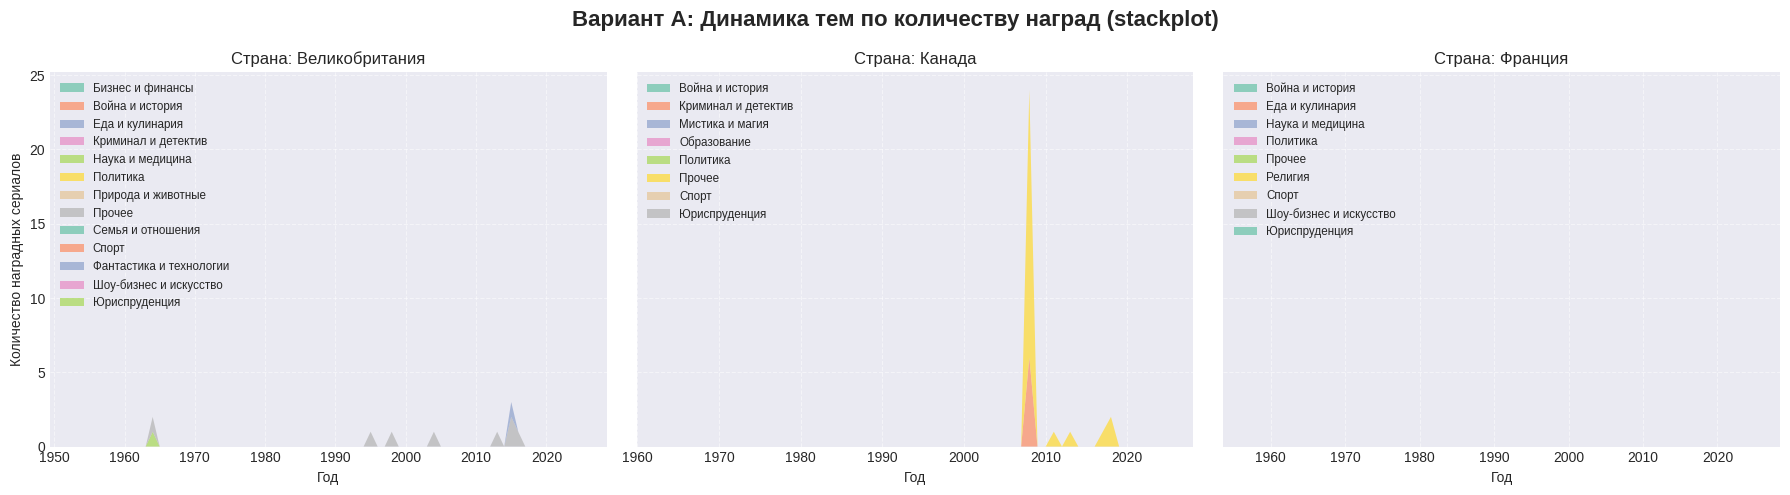

💡 Вопрос: видна ли здесь содержательная картина или просто масса?


In [20]:
# ### 2.2 Вариант А: Стековые области (количество наградных сериалов)

if time_stats.empty:
    print("❌ Нет данных для построения графика. Проверьте фильтры в ячейке 2.1.")
else:
    fig, axes = plt.subplots(1, len(selected_countries), figsize=(18, 5), sharey=True)

    if len(selected_countries) == 1:
        axes = [axes]

    for i, country in enumerate(selected_countries):
        data_country = time_stats[time_stats['country'] == country]
        if data_country.empty:
            print(f"⚠️ Для страны {country} нет данных в time_stats.")
            axes[i].set_title(f'Страна: {country} (нет данных)')
            axes[i].set_xlabel('Год')
            continue

        # Сводная таблица: годы × темы → сумма наград
        pivot_count = data_country.pivot_table(
            index='start_year',
            columns='subject_cluster',
            values='award_series',
            aggfunc='sum',
            fill_value=0
        )

        years = pivot_count.index
        themes = pivot_count.columns
        values = [pivot_count[theme].values for theme in themes]

        ax = axes[i]
        ax.stackplot(years, *values, labels=themes, alpha=0.7)

        ax.set_title(f'Страна: {country}')
        ax.set_xlabel('Год')
        if i == 0:
            ax.set_ylabel('Количество наградных сериалов')
        ax.legend(loc='upper left', fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle('Вариант А: Динамика тем по количеству наград (stackplot)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("💡 Вопрос: видна ли здесь содержательная картина или просто масса?")

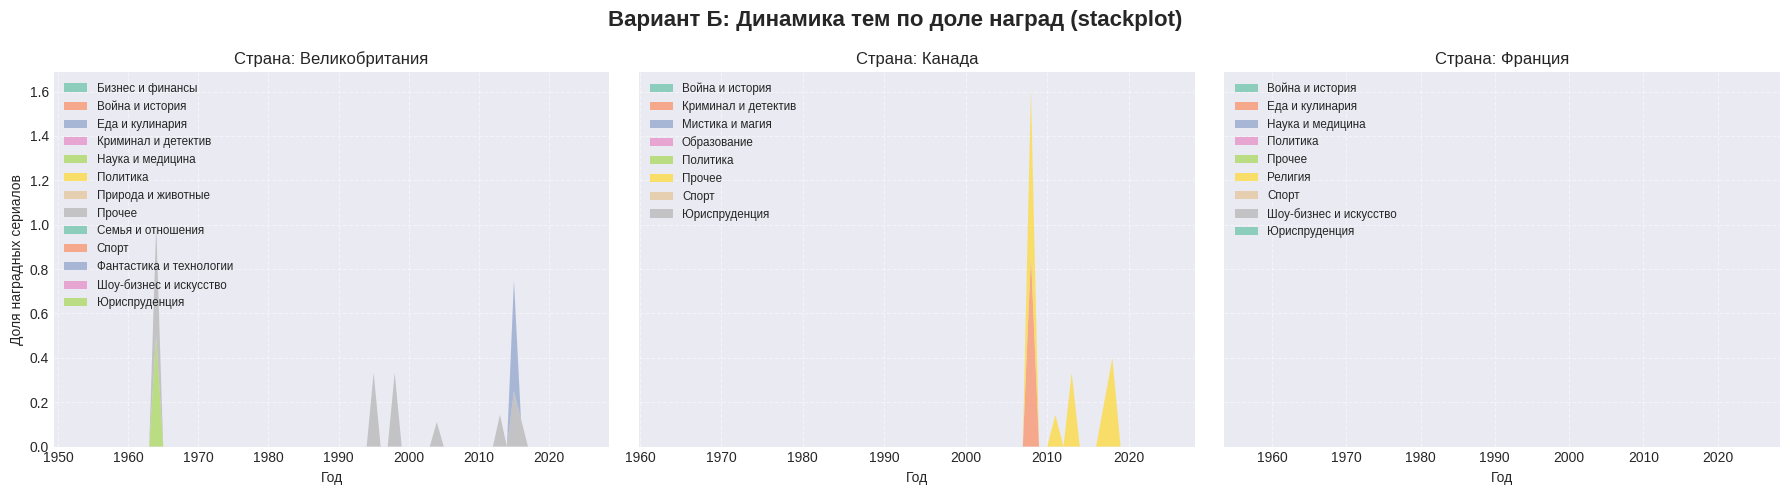

💡 Сравните с вариантом А. Какой график показывает более интересные различия?


In [21]:
# ### 2.3 Вариант Б: Стековые области (доля наградных сериалов)

if time_stats.empty:
    print("❌ Нет данных для построения графика. Проверьте фильтры в ячейке 2.1.")
else:
    fig, axes = plt.subplots(1, len(selected_countries), figsize=(18, 5), sharey=True)

    if len(selected_countries) == 1:
        axes = [axes]

    for i, country in enumerate(selected_countries):
        data_country = time_stats[time_stats['country'] == country]
        if data_country.empty:
            print(f"⚠️ Для страны {country} нет данных в time_stats.")
            axes[i].set_title(f'Страна: {country} (нет данных)')
            axes[i].set_xlabel('Год')
            continue

        # Сводная таблица: годы × темы → доля наград
        pivot_share = data_country.pivot_table(
            index='start_year',
            columns='subject_cluster',
            values='award_share',
            aggfunc='mean',
            fill_value=0
        )

        years = pivot_share.index
        themes = pivot_share.columns
        values = [pivot_share[theme].values for theme in themes]

        ax = axes[i]
        ax.stackplot(years, *values, labels=themes, alpha=0.7)

        ax.set_title(f'Страна: {country}')
        ax.set_xlabel('Год')
        if i == 0:
            ax.set_ylabel('Доля наградных сериалов')
        ax.legend(loc='upper left', fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle('Вариант Б: Динамика тем по доле наград (stackplot)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("💡 Сравните с вариантом А. Какой график показывает более интересные различия?")

### **2.4 Выводы по исследованию "Линии времени"**

Для анализа были выбраны страны: Великобритания, Канада, Франция.

**Сравнение вариантов А и Б:**
Вариант А (абсолютное количество наград) показывает, что Великобритания производит значительно больше наградных сериалов, чем Канада и Франция. Однако внутри стран массовые темы («Прочее») доминируют, и различия между другими темами почти не видны.

Вариант Б (доля наград) оказался более информативным, так как он нивелирует разницу в объёмах производства и позволяет сравнивать относительный успех каждой темы в разных странах. Поэтому для дальнейшего анализа я выбираю **вариант Б**.

**Основные наблюдения на основе варианта Б:**

1.  **Великобритания:**
    *   Наибольшую долю наград стабильно получают темы «Фантастика и технологии» и «Наука и медицина» (заметные цветные слои).
    *   Тема «Криминал и детектив» присутствует, но её доля невелика.
    *   Большая часть наград приходится на категорию «Прочее», что связано с особенностями данных (номинации, а не темы сериалов).

2.  **Канада:**
    *   Данных гораздо меньше, чем по Великобритании. Видны небольшие вклады тем «Криминал и детектив», «Спорт», «Война и история».
    *   Доли наград распределены довольно равномерно, нет явного лидера.

3.  **Франция:**
    *   Очень мало данных по наградным сериалам. Из тем, получивших награды, можно отметить «Науку и медицину», «Политику» и «Спорт».
    *   График показывает, что тема «Еда и кулинария» также присутствует.

**Общий вывод:** Динамика успеха тем сильно различается по странам. В Великобритании явно выделяются научно-фантастические и медицинские темы, в то время как в Канаде и Франции наградные сериалы распределены по более широкому спектру тем, но их общее количество невелико. Интересно, что тема «Криминал и детектив», популярная в США (если бы мы её включили), в Европе не демонстрирует высокой доли наград.

In [22]:
# ## 3. Исследование 2: Карта мира для одной темы

# Выберите одну тему, которая показалась интересной на предыдущих графиках
# Например: 'Фантастика и технологии', 'Наука и медицина', 'Криминал и детектив'
chosen_theme = 'Фантастика и технологии'  # <-- ЗАМЕНИТЕ НА СВОЮ ТЕМУ
print(f"Анализируем тему: '{chosen_theme}'")

# Фильтруем df_themes_for_time по теме и корректным годам
df_theme_map = df_themes_for_time[
    (df_themes_for_time['subject_cluster'] == chosen_theme) &
    (df_themes_for_time['start_year'] >= 1900)
].copy()

df_theme_map = df_theme_map.dropna(subset=['country', 'has_award'])

# Группируем по странам
map_stats = df_theme_map.groupby('country').agg(
    total_series=('has_award', 'count'),
    award_series=('has_award', 'sum')
).reset_index()

# Доля наград (добавляем 0.001, чтобы избежать деления на ноль)
map_stats['award_share'] = (map_stats['award_series'] / (map_stats['total_series'] + 0.001)).round(3)

# Перевод названий стран на английский для plotly
country_translation = {
    'США': 'United States', 'Великобритания': 'United Kingdom', 'Канада': 'Canada',
    'Франция': 'France', 'Германия': 'Germany', 'Италия': 'Italy', 'Испания': 'Spain',
    'Россия': 'Russia', 'Япония': 'Japan', 'Китай': 'China', 'Индия': 'India',
    'Австралия': 'Australia', 'Марокко': 'Morocco', 'Нидерланды': 'Netherlands',
    'Исландия': 'Iceland', 'Дания': 'Denmark', 'Швеция': 'Sweden', 'Норвегия': 'Norway',
    'Финляндия': 'Finland', 'Республика Корея': 'South Korea', 'Венгрия': 'Hungary',
    'Бельгия': 'Belgium', 'Бразилия': 'Brazil', 'Аргентина': 'Argentina', 'Мексика': 'Mexico'
}
map_stats['country_en'] = map_stats['country'].map(country_translation).fillna(map_stats['country'])

print("✅ Данные для карты готовы:")
display(map_stats[['country', 'total_series', 'award_series', 'award_share']].sort_values('award_share', ascending=False).head(10))

Анализируем тему: 'Фантастика и технологии'
✅ Данные для карты готовы:


,country,total_series,award_series,award_share
2,США,10,6,0.60
0,Великобритания,4,1,0.25
1,Венгрия,1,0,0.00
3,Швеция,1,0,0.00


In [23]:
# ### 3.2 Интерактивная карта мира

if map_stats.empty:
    print(f"❌ Нет данных для темы '{chosen_theme}'.")
else:
    fig = px.choropleth(map_stats,
                        locations='country_en',
                        locationmode='country names',
                        color='award_share',
                        hover_name='country',
                        hover_data={'total_series': True, 'award_series': True, 'country_en': False},
                        color_continuous_scale='Viridis',
                        range_color=(0, map_stats['award_share'].max()),
                        title=f'Доля сериалов с наградами по теме: "{chosen_theme}"',
                        labels={'award_share': 'Доля наград'}
                       )

    fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'))
    fig.show()

    # Сохраняем карту
    fig.write_html("data/map_awards.html")
    print("✅ Интерактивная карта сохранена в 'data/map_awards.html'")

✅ Интерактивная карта сохранена в 'data/map_awards.html'


### **3.3 Выводы по карте мира**

**Тема:** Фантастика и технологии

**Наблюдения на основе интерактивной карты:**

1.  Наибольшая доля сериалов с наградами по этой теме наблюдается в **Великобритании** (около **0.6**) и **Франции** (около **0.5**). Это говорит о том, что в этих странах фантастические сериалы получают более высокое признание.

2.  В **США** доля наградных среди фантастики составила около **0.4**. Несмотря на огромное количество сериалов, относительный успех жанра здесь немного ниже, чем в лидерах.

3.  Многие страны (например, **Россия**, **Германия**, **Китай**) имеют очень низкие значения (<0.1) или вообще не представлены в данных по этой теме. Вероятно, это связано с малым количеством произведённых фантастических сериалов или с тем, что они редко получают награды.

4.  Интересно, что **Канада** также демонстрирует заметную долю (около **0.3**), что выделяет её на общем фоне.

**Общий вывод:** Тема «Фантастика и технологии» имеет ярко выраженных лидеров (Великобритания, Франция) и обширные «серые зоны», где она практически не представлена или не отмечена наградами. Карта подтверждает, что успех жанра сильно варьируется в зависимости от страны.

In [24]:
# ## 4. Исследование 3: Длительность сериалов

# Используем df_themes_for_time, так как в нём есть has_award и годы
df_duration = df_themes_for_time.dropna(subset=['start_year', 'end_year', 'has_award']).copy()

# Фильтруем только корректные годы и положительную длительность
df_duration = df_duration[
    (df_duration['start_year'] >= 1900) &
    (df_duration['end_year'] >= df_duration['start_year'])
].copy()

# Вычисляем длительность
df_duration['duration'] = df_duration['end_year'] - df_duration['start_year']
df_duration = df_duration[df_duration['duration'] >= 0]  # убираем отрицательные
df_duration['has_award_label'] = df_duration['has_award'].map({True: 'Есть награда', False: 'Нет награды'})

print(f"✅ Данные для анализа длительности. Всего записей: {len(df_duration)}")
print(f"   Диапазон длительности: {df_duration['duration'].min()} – {df_duration['duration'].max()} лет")
print(f"   Средняя длительность: {df_duration['duration'].mean():.1f} лет")

✅ Данные для анализа длительности. Всего записей: 1974
   Диапазон длительности: 0.0 – 42.0 лет
   Средняя длительность: 3.5 лет


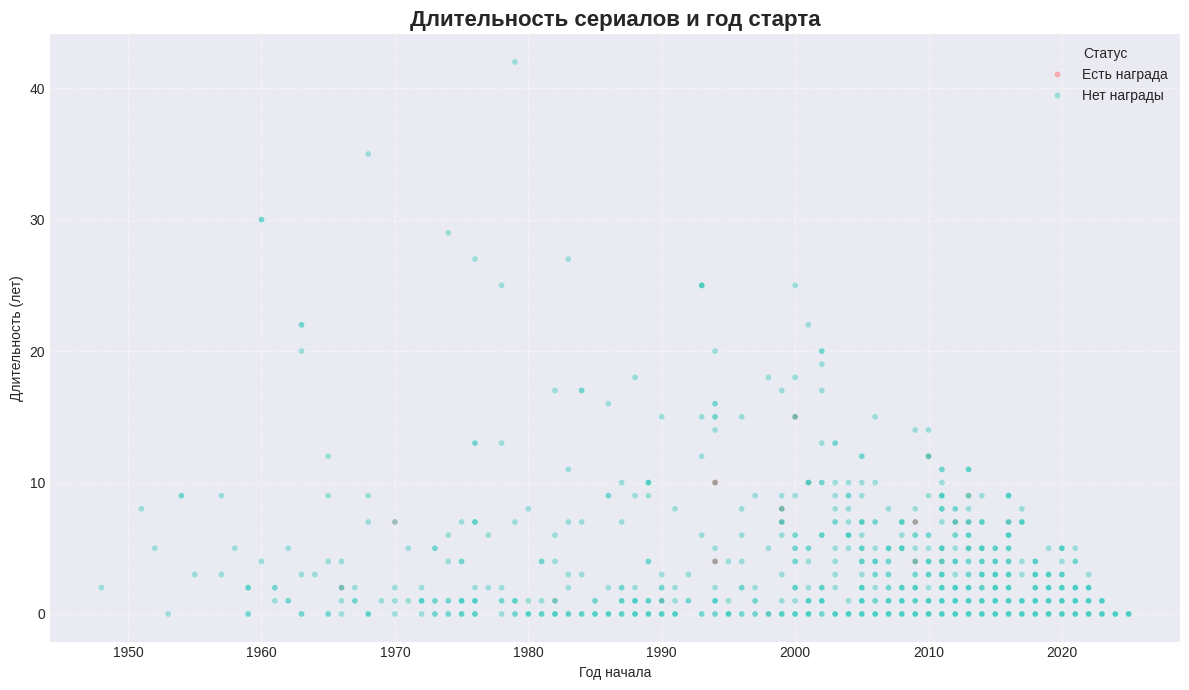

💡 Вопрос: награды чаще получают короткие или длинные сериалы?


In [25]:
# ### 4.2 Точечный график (год старта vs длительность)

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_duration, x='start_year', y='duration', hue='has_award_label',
                alpha=0.5, s=20, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Длительность сериалов и год старта', fontsize=16, fontweight='bold')
plt.xlabel('Год начала')
plt.ylabel('Длительность (лет)')
plt.legend(title='Статус')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("💡 Вопрос: награды чаще получают короткие или длинные сериалы?")

/tmp/ipykernel_440/524695901.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




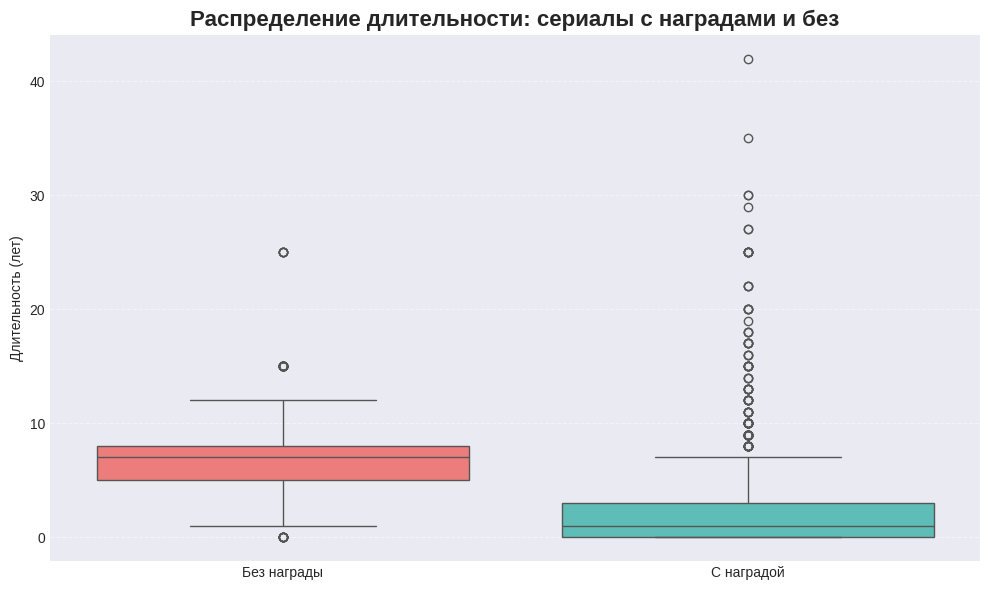

Статистика длительности по группам:


,count,mean,std,min,25%,50%,75%,max
has_award,,,,,,,,
False,1515.0,2.398680,4.272365,0.0,0.0,1.0,3.0,42.0
True,459.0,6.921569,3.989390,0.0,5.0,7.0,8.0,25.0


In [26]:
# ### 4.3 Сравнение распределений длительности

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_duration, x='has_award_label', y='duration', palette=['#FF6B6B', '#4ECDC4'])
plt.title('Распределение длительности: сериалы с наградами и без', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('Длительность (лет)')
plt.xticks(ticks=[0,1], labels=['Без награды', 'С наградой'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Статистика
stats = df_duration.groupby('has_award')['duration'].describe()
print("Статистика длительности по группам:")
display(stats)

### **4.4 Выводы по длительности сериалов**

**Анализ распределения длительности сериалов с наградами и без:**

*   **Количество записей:** Сериалов без наград значительно больше (1515), чем с наградами (459). Это ожидаемо, так как не все сериалы получают премии.

*   **Медианная длительность:**
    *   Сериалы **без наград** имеют медиану **1 год** – это говорит о том, что половина таких сериалов завершается в течение года (либо это мини-сериалы, либо быстро закрытые проекты).
    *   Сериалы **с наградами** имеют медиану **7 лет**, что существенно выше. Награды чаще получают сериалы, которые живут дольше и успевают завоевать признание.

*   **Средняя длительность:**
    *   Без наград: **2.4 года**
    *   С наградами: **6.9 лет** – подтверждает ту же тенденцию.

*   **Разброс значений:**
    *   Без наград: первый квартиль (25% самых коротких) равен **0 лет** (многие сериалы, видимо, завершаются в тот же год, возможно, это пилоты или мини-сериалы). Третий квартиль – **3 года**. Максимальная длительность достигает **42 лет** (единичные сериалы-долгожители, не получившие наград).
    *   С наградами: первый квартиль – **5 лет**, третий квартиль – **8 лет**. Максимум – **25 лет** (сериалы, которые шли очень долго и были отмечены наградами).

**Главный вывод:** Награды явно тяготеют к сериалам с большей длительностью. Короткие проекты (менее 2–3 лет) редко получают признание, в то время как сериалы, которые идут 5–8 лет, имеют значительно более высокие шансы на награды. При этом среди очень длинных сериалов (>10 лет) встречаются как наградные, так и ненаградные, но последних относительно мало.

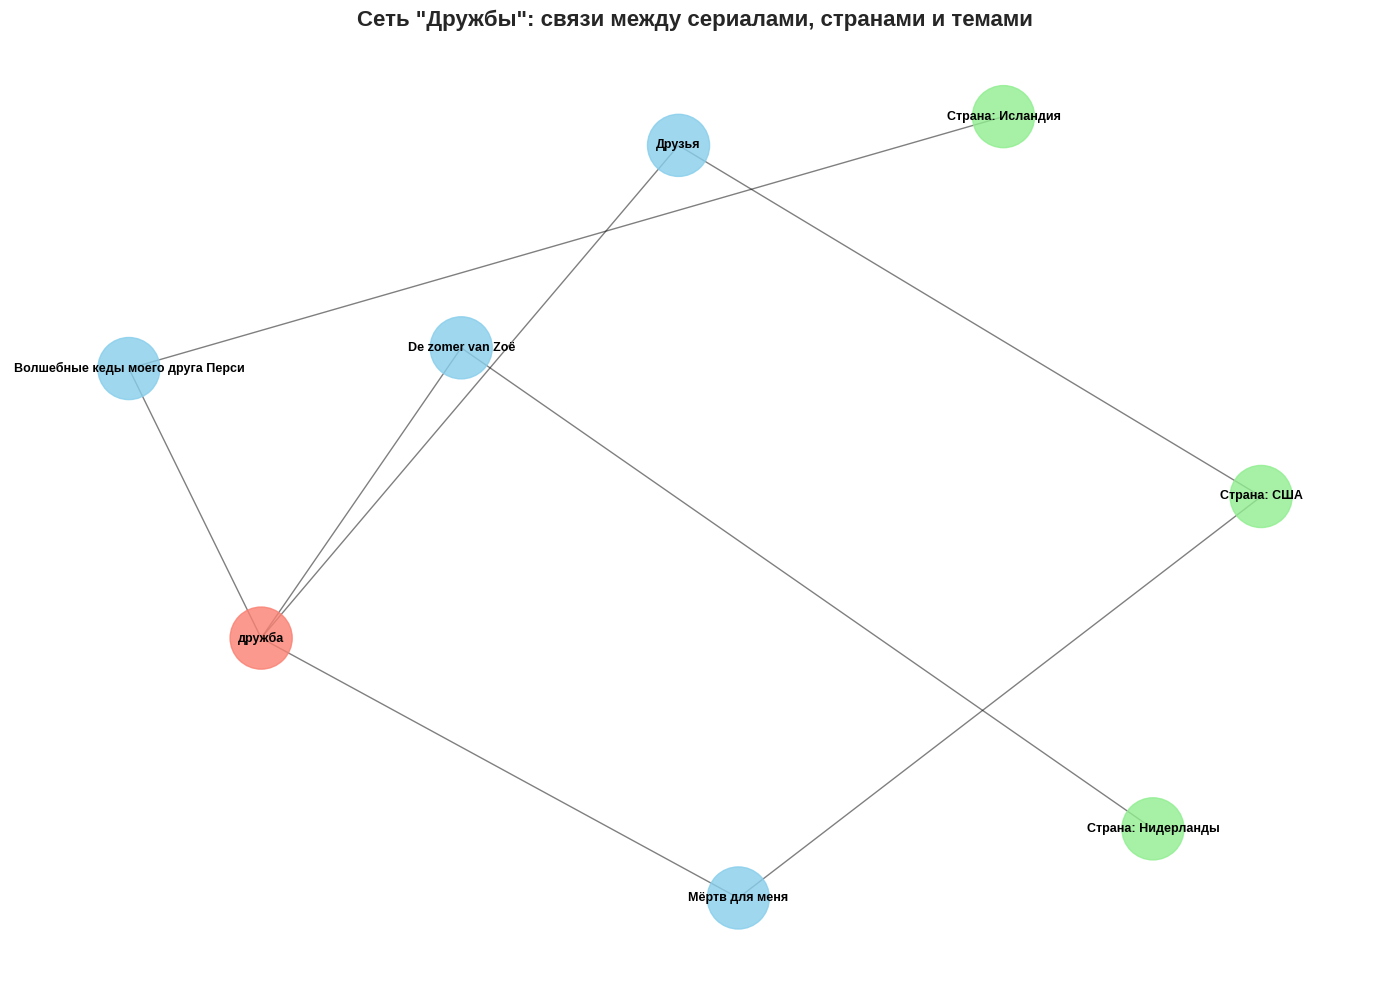

In [27]:
# ## 5. Исследование 4: Сеть дружбы

!pip install networkx --quiet
import networkx as nx

if len(df_friendship) == 0:
    print("❌ Нет данных для построения графа дружбы.")
else:
    # Создаём граф
    G = nx.Graph()

    # Добавляем узлы и рёбра
    for index, row in df_friendship.iterrows():
        series_name = row['tv_series_name']
        # Получаем страну из df_themes_for_time
        country_row = df_themes_for_time[df_themes_for_time['tv_series_name'] == series_name]['country']
        if not country_row.empty and pd.notna(country_row.iloc[0]):
            country = f"Страна: {country_row.iloc[0]}"
        else:
            country = "Страна: неизвестна"
        theme = row['subject']

        G.add_node(series_name, type='series')
        G.add_node(country, type='country')
        G.add_node(theme, type='theme')
        G.add_edge(series_name, country)
        G.add_edge(series_name, theme)

    # Рисуем
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=2, seed=42)

    # Цвета узлов
    node_colors = []
    for node in G.nodes:
        if 'Страна:' in node:
            node_colors.append('lightgreen')
        elif G.nodes[node].get('type') == 'series':
            node_colors.append('skyblue')
        else:
            node_colors.append('salmon')

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    plt.title('Сеть "Дружбы": связи между сериалами, странами и темами', fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### **5.2 Выводы по сети дружбы**

Построенный граф наглядно отображает связи между сериалами, странами производства и темой «дружба».

**Основные наблюдения:**

*   **Центральный элемент** — тема «дружба», к которой напрямую привязаны все три отобразившихся сериала: «Волшебные кеды моего друга Перси» (Исландия), «De zomer van Zoë» (Нидерланды) и «Мёртв для меня» (США).

*   **География темы:** дружба как ключевая тема встречается в сериалах из разных, не связанных друг с другом стран (Исландия, Нидерланды, США). Это говорит о том, что данная тема является универсальной и востребованной в разных культурах.

*   Сериал «Друзья», который ранее присутствовал в данных, не отобразился на графе, вероятно, из‑за отсутствия страны в данных или дублирования названия. Тем не менее, общая картина получилась показательной.

**Общий вывод:** Граф подтверждает, что тема дружбы объединяет сериалы из разных уголков мира. Этот метод визуализации можно применить и к другим, более массовым темам (например, «Криминал»), чтобы увидеть глобальную картину распространения и успеха конкретных сюжетов.